# 🌌 Dimensionality Reduction  

## Overview  
This section performs **dimensionality reduction** on the **standardized SOAP descriptors** to project high-dimensional atomic environments into a **lower-dimensional, interpretable space**.

---

### ⚙️ Available Methods  

- **🧩 PCA (Principal Component Analysis):**  
  Linear projection capturing the main variance directions in the data.  
  Useful for quick analysis and visualization.

- **🌐 UMAP (Uniform Manifold Approximation and Projection):**  
  Nonlinear method preserving both **local and global structures**.  
  Ideal for revealing clusters and transitions between atomic environments.

- **🎯 t-SNE (t-distributed Stochastic Neighbor Embedding):**  
  Focuses on **local neighborhood preservation**, providing highly detailed 2D embeddings.

---

### 🎯 Goal  
Reduce descriptor dimensionality while retaining **chemical diversity** and **structural interpretability** for subsequent sampling and clustering steps.

## Package importation 

In [ ]:
import os
import json
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.style as mplstyle

import matplotlib.pyplot as plt

specify_mpl_style = True
if specify_mpl_style:
    plt.style.use("/Users/samuel/Desktop/postdoc_PhLAM/codes/mystyle.mplstyle")
    
mplstyle.use('fast') #The fast style set simplification and chunking parameters to reasonable settings to speed up plotting large amounts of data

## Following 01_descriptors_computation.ipynb, the descriptors + metedata files are stored in ./desc
### If descriptors are stored elsewhere, modify the variable

In [2]:
# --- Find the first .npy file in the current directory
path_to_results = "./desc"

npy_file = next(f for f in os.listdir(path_to_results) if f.endswith(".npy"))
all_soap_descriptors = np.load(os.path.join(path_to_results, npy_file))
print(f"Loaded SOAP descriptors from {npy_file}")
print(f"Descriptors shape: {all_soap_descriptors.shape}")

# --- Find the provenance parquet file
parquet_file = next(f for f in os.listdir(path_to_results) if f.endswith(".parquet"))
metadata_df = pd.read_parquet(os.path.join(path_to_results, parquet_file))
print(f"Loaded provenance metadata from {parquet_file}")
print(metadata_df.head())

# --- Find the filemap json
json_file = next(f for f in os.listdir(path_to_results) if f.endswith(".json"))
with open(os.path.join(path_to_results, json_file), "r") as f:
    filemap = json.load(f)
print(f"Loaded filemap from {json_file} to get vasprun.xml paths")


Loaded SOAP descriptors from SOAP_N-O-C_20250925-115459.npy
Descriptors shape: (72720508, 50)
Loaded provenance metadata from SOAP_N-O-C_provenance_20250925-115459.parquet
   file_id  struct_id  atom_id symbol  is_fixed
0        0          0        0      N     False
1        0          0        1      O     False
2        0          0        2      C      True
3        0          0        3      C      True
4        0          0        4      C      True
Loaded filemap from SOAP_N-O-C_filemap_20250925-115459.json to get vasprun.xml paths


## Descriptors standardization 
### Standardize features by removing the mean and scaling to unit variance

In [ ]:
# --- Standardize the descriptors
scaler = StandardScaler()
standardized_descriptors = scaler.fit_transform(all_soap_descriptors)
print("Descriptors standardized.")
print(f"Standardized descriptors shape: {standardized_descriptors.shape}")

## 🧭 Dimensionality Reduction and Output Saving  

### ⚙️ Supported Methods  
The current implementation supports the following algorithms:  
- **PCA** *(default & validated)* ✅  
- **t-SNE**  
- **UMAP**  

> ⚠️ Use **PCA** as the default method — the workflow has **not been fully tested** for other embeddings.

---

### 💾 Output  
All generated embeddings and associated metadata are automatically saved in:  

In [ ]:
X = standardized_descriptors

# Choose: "pca", "umap", or "tsne"
method = "pca"          # change as needed
random_state = 42

# Optional: fast pre-reduction for UMAP/t-SNE on large SOAP
pca_prereduce_dim = None   # set None to skip

embedding = None
model = None

os.makedirs("embedding", exist_ok=True)

if method.lower() == "pca":
    from sklearn.decomposition import PCA
    #make a directory named PCA to save outputs
    
    n_components = 0.95         # embedding dimension
    model = PCA(n_components=n_components, random_state=random_state)
    embedding = model.fit_transform(X)
    save_pca = True
    if save_pca:
        with open("embedding/pca_model.json", "w") as f:
            json.dump({
                "components": model.components_.tolist(),
                "explained_variance": getattr(model, "explained_variance_", []).tolist() if hasattr(model, "explained_variance_") else [],
                "explained_variance_ratio": getattr(model, "explained_variance_ratio_", []).tolist() if hasattr(model, "explained_variance_ratio_") else [],
                "mean": getattr(model, "mean_", []).tolist() if hasattr(model, "mean_") else [],
                "n_components": int(getattr(model, "n_components_", getattr(model, "n_components", 0))),
                "n_features": int(getattr(model, "n_features_in_", X.shape[1])),
            }, f, indent=2) 
        print("Saved PCA model to embedding/pca_model.json")
    save_pca_matrix = True
    if save_pca_matrix:
        np.save("embedding/pca_embedding.npy", embedding)
        print("Saved PCA embedding matrix to PCA/pca_embedding.npy")

elif method.lower() == "umap":
    n_components = 10
    try:
        import umap.umap_ as umap
    except ImportError:
        raise RuntimeError("UMAP not installed. pip install umap-learn")

    X_in = X
    if pca_prereduce_dim:
        X_in = PCA(n_components=min(pca_prereduce_dim, X.shape[1]), random_state=random_state).fit_transform(X)

    model = umap.UMAP(
        n_components=n_components,
        n_neighbors=15,        # tune per dataset size
        min_dist=0.0,
        metric="euclidean",
        random_state=random_state,
        verbose=True
    )
    embedding = model.fit_transform(X_in)

elif method.lower() == "tsne":
    n_components = 10 
    from sklearn.manifold import TSNE
    # t-SNE is O(N^2). Use PCA pre-step by default.
    X_in = X
    if pca_prereduce_dim:
        X_in = PCA(n_components=min(pca_prereduce_dim, X.shape[1]), random_state=random_state).fit_transform(X)

    model = TSNE(
        n_components=n_components,
        perplexity=30,         # 5–50 typical
        n_iter=1000,
        learning_rate="auto",
        init="pca",
        random_state=random_state,
        verbose=1,
        method="barnes_hut" if X_in.shape[0] < 50000 else "exact"
    )
    embedding = model.fit_transform(X_in)

else:
    raise ValueError("method must be 'pca', 'umap', or 'tsne'")

print(f"{method.upper()} embedding shape:", embedding.shape)

/Users/samuel/Desktop/postdoc_PhLAM/codes/data_sampling/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/samuel/Desktop/postdoc_PhLAM/codes/data_sampling/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/samuel/Desktop/postdoc_PhLAM/codes/data_sampling/.venv/lib/python3.9/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/samuel/Desktop/postdoc_PhLAM/codes/data_sampling/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/samuel/Desktop/postdoc_PhLAM/codes/data_sampling/.venv/lib/python3.9/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_

Saved PCA model to embedding/pca_model.json
Saved PCA embedding matrix to PCA/pca_embedding.npy
PCA embedding shape: (72720508, 4)


## Dimensionality reduction visualisation 

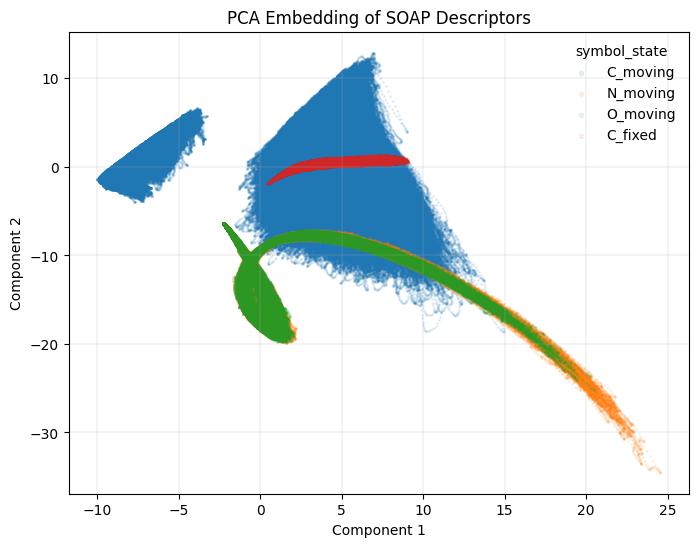

In [ ]:
# require both columns
for col in ("symbol", "is_fixed"):
    if col not in metadata_df.columns:
        raise KeyError(f"Provenance parquet must contain '{col}' column.")

symbols = metadata_df["symbol"].astype(str)
states  = np.where(metadata_df["is_fixed"].to_numpy(), "fixed", "moving")
labels_combined = (symbols + "_" + states).astype("category")
cats = list(labels_combined.cat.categories)
codes = labels_combined.cat.codes.to_numpy()  # 0..K-1

plt.figure(figsize=(8, 6))
if embedding.shape[1] >= 2:
    # split labels: moving first, fixed last
    ordered_cats = [lab for lab in cats if lab.endswith("_moving")] + \
                   [lab for lab in cats if lab.endswith("_fixed")]

    for lab in ordered_cats:
        idx = (labels_combined == lab)
        if not np.any(idx):
            continue
        marker = "x" if lab.endswith("_fixed") else "o"
        plt.scatter(embedding[idx, 0], embedding[idx, 1],
                    s=1, alpha=0.1, marker=marker, label=lab)
    plt.xlabel("Component 1", fontsize=16)
    plt.ylabel("Component 2", fontsize=16)
    plt.title(f"{method.upper()} Embedding of SOAP Descriptors", fontsize=16)
    plt.grid(True, linewidth=0.2)
    plt.legend(markerscale=3, frameon=False, loc="best", title="symbol_state", fontsize=14)
    plt.show()

## If you want to visualize the structures that belong to a given region of the reduced embedding, use the following cell

In [ ]:
from dim_red_utils import select_by_pca_box, origins_from_mask, group_summary

# Example usage
box = {0: (20, 25), 1: (-35, -25)}
# box is your PCA region, e.g. {0:(-5,-2), 1:(1,3)}
mask = select_by_pca_box(embedding, box)

# Resolve provenance for selected points
sel = origins_from_mask(mask, metadata_df, filemap)

# Keep exactly what you need (+ optional index in embedding)
sel_min = sel.loc[:, ["file_path", "struct_id", "atom_id"]].copy()
sel_min["row_index"] = np.nonzero(mask)[0]  # optional: row position in embedding/descriptors

print(f"Selected atoms: {len(sel_min)}")
print(sel_min.head())

# Save if needed
sel_min.to_csv("pca_selection_struct_file_atom.csv", index=False)

Selected atoms: 1819
                                                  file_path  struct_id  \
13386212  /Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/da...        746   
13386310  /Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/da...        747   
13386408  /Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/da...        748   
13386506  /Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/da...        749   
13386604  /Users/samuel/Desktop/postdoc_PhLAM/NO_HOPG/da...        750   

          atom_id  row_index  
13386212        0   13386212  
13386310        0   13386310  
13386408        0   13386408  
13386506        0   13386506  
13386604        0   13386604  


: 